In [5]:
productos = c(rep(1,10),rep(2,5),rep(3,5),rep(0,80))
productos_revueltos = sample(productos,100)
productos_revueltos

[1] 0 0 0 0 0 0 0 0 1 0 0 3 0 1 2 2 0 0 0 0 1 0 0 0 2 0 0 0 0 0 3 0 0 0 0 0 0
 [38] 0 0 0 0 0 0 1 0 0 2 0 0 1 0 0 1 3 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0
 [75] 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 3 0 0 0 0 0 3 0 0

In [6]:
evento_A = c(1,3)
evento_B = c(2,3)
evento_AyB = c(3)

In [83]:
tamaño = 50
muestra = sample(productos_revueltos,size=tamaño,replace=FALSE)
muestra

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 3 0 0 2 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0
[39] 1 0 0 0 3 0 0 0 0 0 0 1

In [84]:
## Probabilidad de tener algún defecto
(sum(muestra %in% evento_A)+sum(muestra %in% evento_B)-sum(muestra %in% evento_AyB))/tamaño

[1] 0.18

In [33]:
## Probabilidad de tener únicamente defecto estético
(sum(muestra %in% evento_A)-sum(muestra %in% evento_AyB))/tamaño

[1] 0.1

In [34]:
mi_vector = c(1,4,2,78,2,9,-1,0,2026)
length(mi_vector)

[1] 9

In [35]:
sample(mi_vector,size=9)

[1]   78    9    0    2    1 2026    2    4   -1

In [63]:
####################################################### simulacion para varios tamaños

simulacion = function(tamaño){
  muestra = sample(productos_revueltos,size=tamaño,replace=FALSE)
  return((sum(muestra %in% evento_A)+sum(muestra %in% evento_B)-sum(muestra %in% evento_AyB))/tamaño)
}


In [75]:
resultados = sapply(1:100,simulacion)
simulaciones = data.frame("tamaño"=1:100,"probabilidad"=resultados)
simulaciones

tamaño,probabilidad
<int>,<dbl>
1,0.00000000
2,0.00000000
3,0.00000000
4,0.00000000
5,0.20000000
6,0.00000000
7,0.28571429
8,0.12500000
9,0.33333333


In [69]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


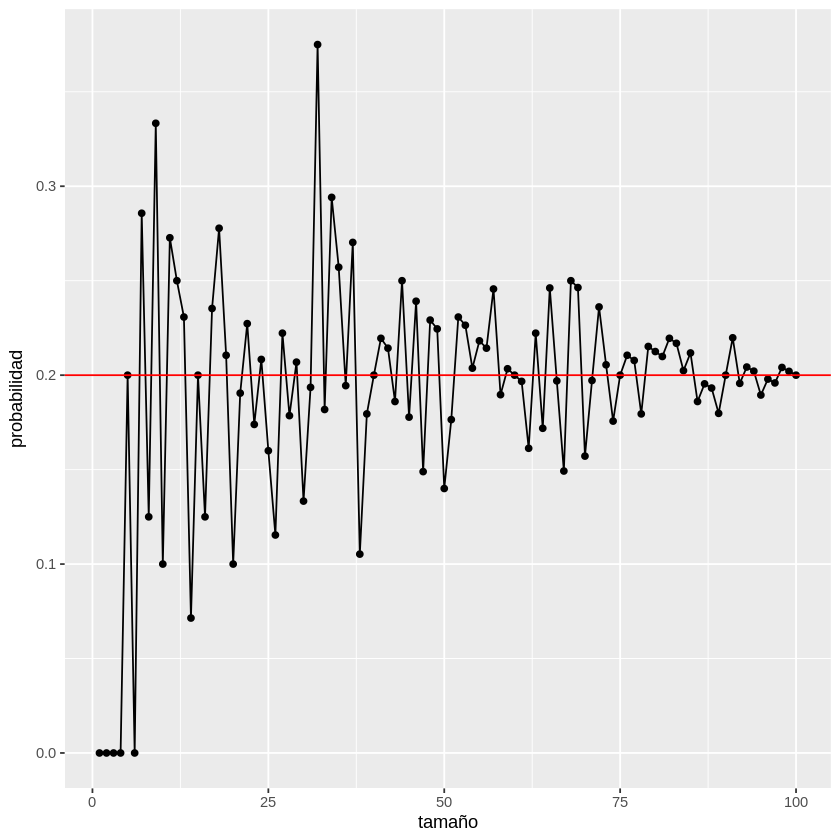

In [76]:
ggplot(data = simulaciones) +
  geom_point(mapping=aes(x=tamaño,y=probabilidad)) +
  geom_line(mapping=aes(x=tamaño,y=probabilidad)) +
  geom_hline(yintercept=0.2,color="red")